In [1]:
import sympy as sp
import numpy as np
from matplotlib import pyplot as plt

Labor Disutility

In [2]:
L = sp.symbols("L", positive=True)
l = sp.symbols("lambda", positive=True)
labor_disutility = -l * sp.log(1 - L)
labor_disutility

-lambda*log(1 - L)

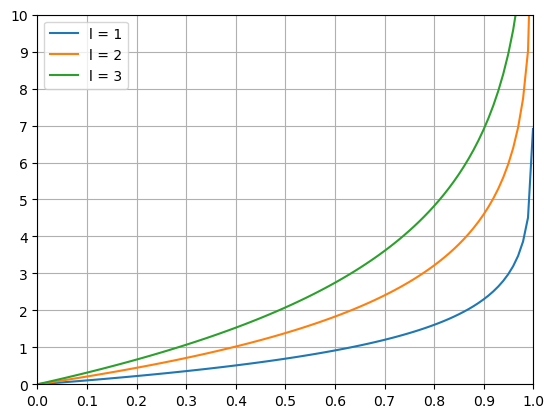

In [3]:
l_values = np.linspace(0, .999, 101)

fig, ax = plt.subplots()
ax.set_xticks(np.linspace(0, 1, 11))
ax.set_yticks(np.linspace(0, 10, 11))
ax.set_xlim(0, 1)
ax.set_ylim(0, 10)
ax.plot(l_values, np.array([labor_disutility.subs(L, l_value).subs(l, 1) for l_value in l_values]), label="l = 1")
ax.plot(l_values, np.array([labor_disutility.subs(L, l_value).subs(l, 2) for l_value in l_values]), label="l = 2")
ax.plot(l_values, np.array([labor_disutility.subs(L, l_value).subs(l, 3) for l_value in l_values]), label="l = 3")
ax.legend()
ax.grid()

Consumption Utility

In [4]:
C = sp.symbols("C", positive=True)
C0 = sp.symbols("C_0", positive=True)

consumption_utility = sp.Piecewise(((C - C0)/C0, C >= C0), (sp.log(C/C0), True))
consumption_utility

Piecewise(((C - C_0)/C_0, C >= C_0), (log(C/C_0), True))

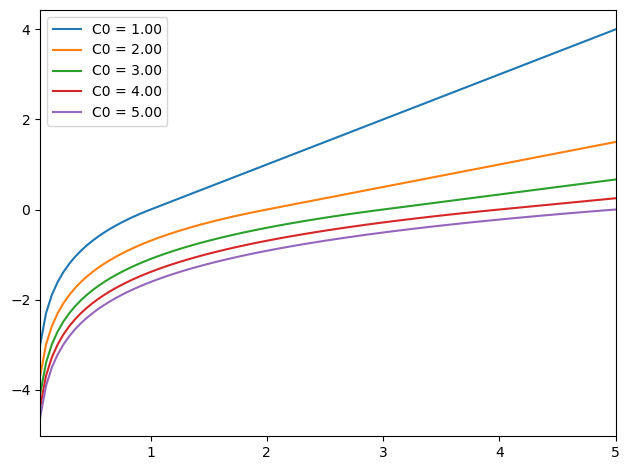

In [5]:
c_values = np.linspace(0, 5, 101)[1:]
c_ticks = c_values[::20]
c_tickslabels = [f"{c_tick:2.2f}" for c_tick in c_ticks]

fig, ax = plt.subplots()
ax.set_xlim(c_values.min(), c_values.max())
for c0 in np.linspace(1, 5, 5):
    ax.plot(c_values, np.array([consumption_utility.subs(C, c_value).subs(C0, c0) for c_value in c_values]), label=f"C0 = {c0:2.2f}")
ax.legend()

fig.tight_layout()

Wealth Utility

In [6]:
W = sp.symbols("W", positive=True)
W0 = sp.symbols("W_0", positive=True)

wealth_utility = sp.sqrt(W/W0)

Optimization

In [7]:
S, P = sp.symbols("S P", positive=True)
r = sp.symbols("r", positive=True)
T = sp.symbols("T", positive=True, integer=True)

utility_1 = wealth_utility.subs(W, W + (L*S - C*P)*T) * r ** T + (consumption_utility - labor_disutility) * (1 -r**T)/(1 - r)
utility_1

(1 - r**T)*(lambda*log(1 - L) + Piecewise(((C - C_0)/C_0, C >= C_0), (log(C/C_0), True)))/(1 - r) + r**T*sqrt(T*(-C*P + L*S) + W)/sqrt(W_0)

Def:
$$
M = W_0 \left(\frac{(1 - r^T)}{r^T (1-r)}\right)^2
$$

In [8]:
M = sp.symbols("M", positive=True)
utility = wealth_utility.subs(W, (W + (L*S - C*P)*T)).subs(W0, M) + (consumption_utility - labor_disutility)
utility

lambda*log(1 - L) + Piecewise(((C - C_0)/C_0, C >= C_0), (log(C/C_0), True)) + sqrt(T*(-C*P + L*S) + W)/sqrt(M)

In [9]:
solutions = sp.solve(sp.simplify(sp.diff(utility, C)))

In [10]:
solutions[0][C]

Piecewise((2*(sqrt(M)*sqrt(L*S*T + M + W) - M)/(P*T), C_0 > 2*(sqrt(M)*sqrt(L*S*T + M + W) - M)/(P*T)), (nan, True))

In [11]:
solutions[1][C]

Piecewise((-C_0**2*P*T/(4*M) + L*S/P + W/(P*T), C_0 <= (-C_0**2*P**2*T**2 + 4*L*M*S*T + 4*M*W)/(4*M*P*T)), (nan, True))

Notices that both conditions are exact oposites. The first is equivalent to:

$$
\left(\frac{C_0PT}{2}\right)^2 > M (W + LST - C_0 PT)
$$

and the second to:

$$
\left(\frac{C_0PT}{2}\right)^2 \le M (W + LST - C_0 PT)
$$

In [15]:
c_1 = solutions[0][C].args[0][0]
cond_1 = solutions[0][C].args[0][1]

c_2 = solutions[1][C].args[0][0]
cond_2 = solutions[1][C].args[0][1]

c_opt = sp.Piecewise((c_1, cond_1), (c_2, True))
c_opt

Piecewise((2*(sqrt(M)*sqrt(L*S*T + M + W) - M)/(P*T), C_0 > 2*(sqrt(M)*sqrt(L*S*T + M + W) - M)/(P*T)), (-C_0**2*P*T/(4*M) + L*S/P + W/(P*T), True))

In [18]:
utility_labor = sp.simplify(utility.subs(C, c_opt))
utility_labor

Piecewise(((sqrt(M)*(lambda*log(1 - L) + log(2*(sqrt(M)*sqrt(L*S*T + M + W) - M)/(C_0*P*T))) + sqrt(L*S*T - 2*sqrt(M)*sqrt(L*S*T + M + W) + 2*M + W))/sqrt(M), C_0 > 2*(sqrt(M)*sqrt(L*S*T + M + W) - M)/(P*T)), (C_0*P*T/(4*M) + lambda*log(1 - L) - 1 + L*S/(C_0*P) + W/(C_0*P*T), C_0 <= -C_0**2*P*T/(4*M) + L*S/P + W/(P*T)), (C_0*P*T/(2*M) + lambda*log(1 - L) + log(-C_0**2*P**2*T**2 + 4*L*M*S*T + 4*M*W) - log(2**(4*M)*C_0**(2*M)*M**(2*M)*P**(2*M)*T**(2*M))/(2*M), True))

Note that conditions 1 and 2 above are exact opposites, and condition 1 is exactly the same as `cond_1` above

In [26]:
utility_labor_2 = sp.Piecewise((utility_labor.args[0][0], cond_1), (utility_labor.args[1][0], True))
utility_labor_2

Piecewise(((sqrt(M)*(lambda*log(1 - L) + log(2*(sqrt(M)*sqrt(L*S*T + M + W) - M)/(C_0*P*T))) + sqrt(L*S*T - 2*sqrt(M)*sqrt(L*S*T + M + W) + 2*M + W))/sqrt(M), C_0 > 2*(sqrt(M)*sqrt(L*S*T + M + W) - M)/(P*T)), (C_0*P*T/(4*M) + lambda*log(1 - L) - 1 + L*S/(C_0*P) + W/(C_0*P*T), True))

In [235]:
a = sp.Symbol("a")

some_values = (utility + a * sp.erf(L - 1))\
    .subs(M, 1)\
    .subs(r, 0.9)\
    .subs(T, 10)\
    .subs(S, 2)\
    .subs(P, 1)\
    .subs(l, 3)\
    .subs(W, 0.0)\
    .subs(C0, 0.5)


[sp.diff(some_values , L), sp.diff(some_values, a)]

[2*a*exp(-(L - 1)**2)/sqrt(pi) + 10/sqrt(-10*C + 20*L) - 3/(1 - L), erf(L - 1)]

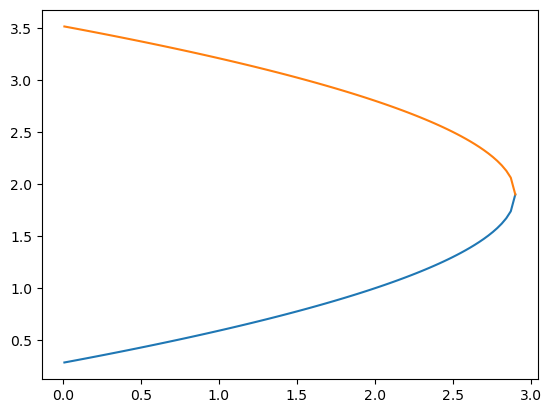

In [228]:
xs = np.linspace(0.01, 2.90, 101)

fig, ax = plt.subplots()
for solution in solutions:
    ys = np.array([solution.subs(C, x) for x in xs])
    plt.plot(xs, ys)
    